# MFAA Chapter 6 Laboratory
**NAV Unsmoothing and Hidden-Value Reconstruction** (book §6.9)

Reconstruct latent value by Kalman filtering with credible bands; report marks as posterior distributions. The habit: never quote a private-asset moment without stating the filtration and the band. Seed `20260600`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch06
from dataclasses import replace

## 1. E2 — the committee's three volatilities (Proposition 6.3)
Reported variance understates latent by (1−α)/(1+α); autocorrelation is αᵏ.

In [2]:
p = ch06.FilterParams(alpha=0.6, n=20000)
m = ch06.smoothing_moments(p)
print(f"variance ratio: sample {m['var_ratio_sample']:.4f}, theory {m['var_ratio_theory']:.4f}")
print(f"lag-1 autocorrelation: sample {m['rho1_sample']:.4f}, theory {p.alpha}")
print(f"variance-correction factor (1+α)/(1−α): {m['correction_factor']:.4f}")

variance ratio: sample 0.2487, theory 0.2500
lag-1 autocorrelation: sample 0.5971, theory 0.6
variance-correction factor (1+α)/(1−α): 4.0000


## 2. Kalman reconstruction with credible bands

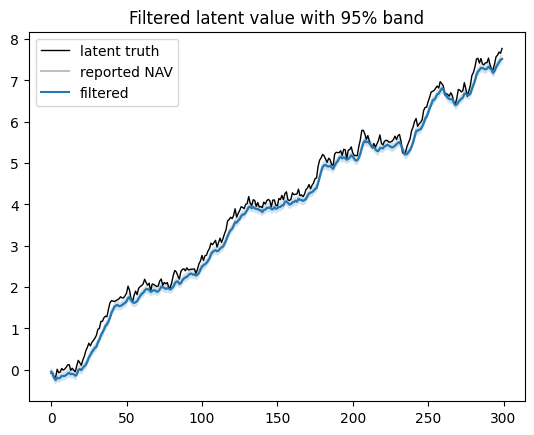

In [3]:
kf = ch06.kalman_filter(ch06.FilterParams(n=300, sigma_eps=0.02))
t = np.arange(len(kf['truth']))
plt.plot(t, kf['truth'], 'k-', lw=1, label='latent truth')
plt.plot(t, kf['y'], color='grey', alpha=.5, label='reported NAV')
plt.plot(t, kf['filtered'], 'C0-', label='filtered')
sd = np.sqrt(kf['filtered_var'])
plt.fill_between(t, kf['filtered']-2*sd, kf['filtered']+2*sd, alpha=.2)
plt.legend(); plt.title('Filtered latent value with 95% band');

## 3. E4 — Overcorrection stress (Section 6.8)
Naive Geltner inversion with a misestimated α̂ manufactures volatility.

In [4]:
import pandas as pd
pd.DataFrame(ch06.overcorrection_stress(ch06.FilterParams(sigma_eps=0.03)))

,alpha_hat,inverted_vol,true_vol,noise_amp_theory
0,0.4,0.099174,0.102738,0.00780
1,0.5,0.120721,0.102738,0.01260
2,0.6,0.154613,0.102738,0.02205
3,0.7,0.213049,0.102738,0.04380
4,0.8,0.332572,0.102738,0.10980


## 4. Validation checks

In [5]:
v = ch06.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_moments PASS
V2_geltner_exact PASS
V3_correction_factor PASS
V4_smoother_tighter PASS
V5_whiteness PASS
V6_reproducible PASS
ALL: True
